# **Introduction to Image Generation with Stable Diffusion Pipeline**

### **Objective:**  
To generate images from text prompts using the **Stable Diffusion pipeline**, demonstrating how AI models transform textual descriptions into high-quality visuals.

---

### **Note:**  

- Before running any demo, ensure that the **`requirements.txt`** file is installed. This file contains all the required dependencies for **all demos and guided practices under _Image Generation Capabilities_**.
- Install the dependencies using the following command in the terminal: (Run this command twice if the packages are not installed properly)

    **pip install -r requirements.txt**

- The installation process may take around 10- 15 minutes, once installed you select the kernal of that virtual environment


---

### **Steps to perform:**
1. Setup the Environment
2. Import the necessary libraries  
3. Load the pretrained model  
4. Move to GPU if available  
5. Initialize list to store images  

---


### __Step 2: Import the neccessary libraries__

- Import **torch** for PyTorch functionality
- Import **StableDiffusionPipeline** from `diffusers` to generate images from text
- Import **matplotlib** for displaying generated images

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install diffusers[torch] transformers accelerate safetensors xformers matplotlib

Looking in indexes: https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 43.9 MB/s eta 0:00:00


In [2]:
import os
import matplotlib.pyplot as plt
import torch
from diffusers import StableDiffusionPipeline


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


### __Step 3: Load the pretrained model__
- Define the model identifier (model_id) for the Stable Diffusion v1.5 model
- Load the pretrained model using StableDiffusionPipeline.from_pretrained, setting torch_dtype=torch.float16 for efficiency

In [3]:
# Load the Stable Diffusion pipeline
model_id = "runwayml/stable-diffusion-v1-5"

pipeline = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

print("✅ Model loaded successfully.")


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

✅ Model loaded successfully.


### __Step 4: Move to GPU if available__
- Move the pipeline to GPU using .to("cuda") for faster processing if a GPU is available.
- Create a list of textual prompts (image_prompts) that will be used to generate images.
- Each prompt describes a scene or concept.

In [4]:
# Move model to GPU (if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = pipeline.to(device)
print(f"✅ Pipeline moved to device: {device}")

# Define image prompts
image_prompts = [
    "A futuristic sports car",
    "A futuristic sports car, cinematic lighting",
    "A futuristic sports car, cinematic lighting, ultra realistic",
    "A futuristic sports car, cinematic lighting, ultra realistic, 8k, highly detailed",
    "A futuristic sports car, cyberpunk city background, neon lights, cinematic, highly detailed"
]


✅ Pipeline moved to device: cuda


### __Step 5: Initailize list to store images__
- Create an empty list to store generated images
- For each prompt, generate an image using the pipeline
- Save the images to a local folder and display them inline


🎨 Generating image 1 for prompt: 'A futuristic sports car'


  0%|          | 0/50 [00:00<?, ?it/s]

✅ Image saved as: generated_images/image_1.jpg

🎨 Generating image 2 for prompt: 'A futuristic sports car, cinematic lighting'


  0%|          | 0/50 [00:00<?, ?it/s]

✅ Image saved as: generated_images/image_2.jpg

🎨 Generating image 3 for prompt: 'A futuristic sports car, cinematic lighting, ultra realistic'


...

✅ Image saved as: generated_images/image_3.jpg

🎨 Generating image 4 for prompt: 'A futuristic sports car, cinematic lighting, ultra realistic, 8k, highly detailed'


  0%|          | 0/50 [00:00<?, ?it/s]

✅ Image saved as: generated_images/image_4.jpg

🎨 Generating image 5 for prompt: 'A futuristic sports car, cyberpunk city background, neon lights, cinematic, highly detailed'


  0%|          | 0/50 [00:00<?, ?it/s]

✅ Image saved as: generated_images/image_5.jpg


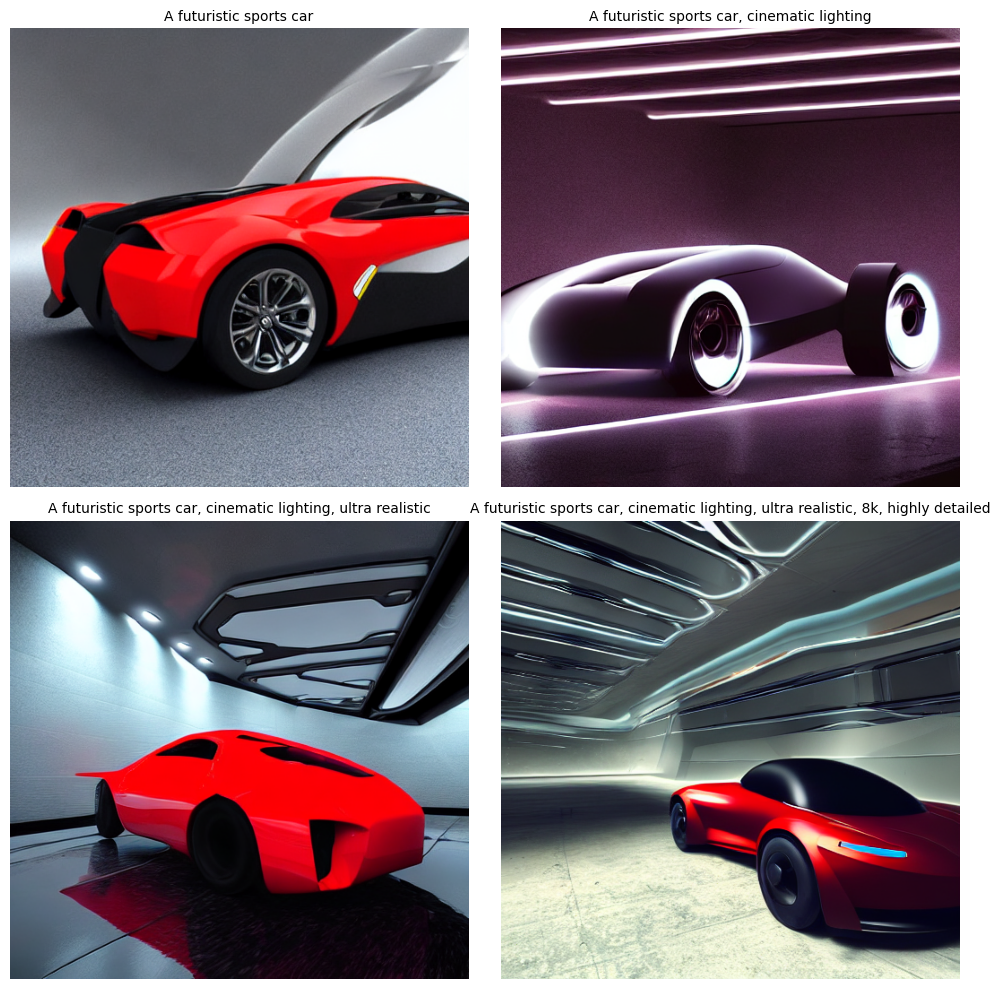

✅ All generated images displayed successfully.


In [5]:
# Create folder to save generated images
os.makedirs("generated_images", exist_ok=True)

# Initialize list to store generated images
generated_images = []

# Generate, save, and display images
for i, prompt in enumerate(image_prompts):
    print(f"\n🎨 Generating image {i+1} for prompt: '{prompt}'")

    # Generate image from prompt
    image = pipeline(prompt).images[0]

    # Save image
    image_path = f"generated_images/image_{i+1}.jpg"
    image.save(image_path)
    print(f"✅ Image saved as: {image_path}")

    # Append to list
    generated_images.append(image)

# Display all generated images in a 2×2 grid
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, img, prompt in zip(axes.flat, generated_images, image_prompts):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(prompt, fontsize=10)

plt.tight_layout()
plt.show()

print("✅ All generated images displayed successfully.")


- These images will be stored inside the generated_images folder

### __Conclusion__
The demo illustrated how to generate images from text prompts using the Stable Diffusion pipeline, showcasing AI's potential in creative fields. It covered setup, model loading, GPU utilization, and the generation process, emphasizing AI's role in transforming artistic expression and innovation.

---